In [21]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from helper.plot import plot_prof
from helper.diff_fit import diff_free, diff_global, diff_csglobal, diff_dglobal, diff_csfixed
from helper.diff_utils import diff_profile
import scipy
from scipy.optimize import curve_fit
from scipy.special import erfc

In [22]:
# ---- Loading data ----
import sys

if sys.platform == "win32": # windows
    depth_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_x.csv', dtype = float)
    time_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_time.csv', dtype = float)
    conc_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_conc_xt.csv', dtype = float)

elif sys.platform == "darwin": # mac
    depth_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_x.csv', dtype = float)
    time_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_time.csv', dtype = float)
    conc_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_conc_xt.csv', dtype = float)

In [23]:
# convert to np arrayx
depth = np.asarray(depth_df, dtype = float).flatten()
time = np.asarray(time_df, dtype = float).flatten()
conc = np.asarray(conc_df, dtype = float)

# Experimental Profile

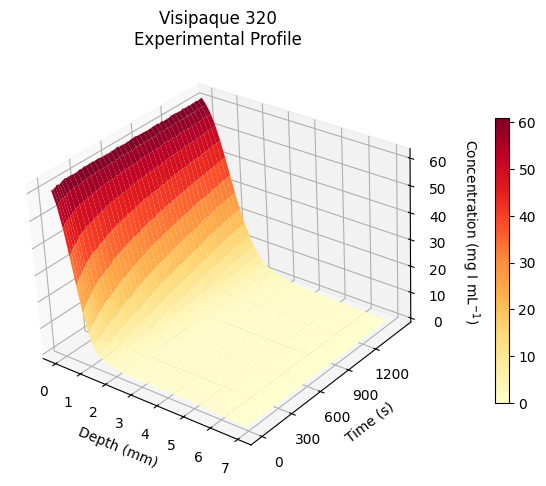

In [26]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# Model Fitting
$$C(x,t) = C_s\cdot\operatorname{erfc}\left(\frac{x}{2\sqrt{Dt}}\right)$$

## 1. Free D and Cs

In [27]:
opt_free = diff_free(c_xt = conc, x = depth, time = time)

--------
Reporting Results
--------
t = 10.0 s: D = 3.186e-02, SE = 1.508e-03 (95% CI [2.881e-02, 3.490e-02]), Cs = 65.323, SE = 1.081 (95% CI [63.140, 67.507]), R2 = 0.9910, D-Cs corr = -0.572
t = 20.0 s: D = 1.668e-02, SE = 7.734e-04 (95% CI [1.512e-02, 1.824e-02]), Cs = 65.208, SE = 1.060 (95% CI [63.068, 67.348]), R2 = 0.9913, D-Cs corr = -0.574
t = 30.0 s: D = 1.118e-02, SE = 5.433e-04 (95% CI [1.008e-02, 1.228e-02]), Cs = 65.816, SE = 1.121 (95% CI [63.552, 68.080]), R2 = 0.9905, D-Cs corr = -0.574
t = 40.0 s: D = 8.651e-03, SE = 4.123e-04 (95% CI [7.819e-03, 9.484e-03]), Cs = 65.824, SE = 1.101 (95% CI [63.600, 68.047]), R2 = 0.9908, D-Cs corr = -0.575
t = 50.0 s: D = 7.006e-03, SE = 3.300e-04 (95% CI [6.339e-03, 7.672e-03]), Cs = 66.309, SE = 1.097 (95% CI [64.094, 68.524]), R2 = 0.9910, D-Cs corr = -0.575
t = 60.0 s: D = 5.986e-03, SE = 2.943e-04 (95% CI [5.392e-03, 6.580e-03]), Cs = 66.485, SE = 1.149 (95% CI [64.164, 68.806]), R2 = 0.9901, D-Cs corr = -0.576
t = 70.0 s: D = 

In [28]:
corrfree_per_t = opt_free['corr_per_t']
valid_idx = np.where(np.isfinite(opt_free["cs_per_t"]))[0]

print("--------")
print("D-Cs correlations per timepoint")
print("--------")
corr_summary = {}
pos_corr = {}

for t_idx in valid_idx:
    corr_t = corrfree_per_t[t_idx][0, 1]  # 2x2 matrix, D-Cs is [0,1]
    label = f"t={time[t_idx]}s"
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3:
        pos_corr[label] = corr_t

if not pos_corr:
    print("Weak to no correlations detected.")
else:
    print("Moderate to strong correlations detected:")
    for label, val in pos_corr.items():
        print(f"  D vs Cs at {label}: {val:.3f}")

--------
D-Cs correlations per timepoint
--------
Moderate to strong correlations detected:
  D vs Cs at t=10.0s: -0.572
  D vs Cs at t=20.0s: -0.574
  D vs Cs at t=30.0s: -0.574
  D vs Cs at t=40.0s: -0.575
  D vs Cs at t=50.0s: -0.575
  D vs Cs at t=60.0s: -0.576
  D vs Cs at t=70.0s: -0.577
  D vs Cs at t=80.0s: -0.577
  D vs Cs at t=90.0s: -0.578
  D vs Cs at t=100.0s: -0.578
  D vs Cs at t=110.0s: -0.579
  D vs Cs at t=130.0s: -0.580
  D vs Cs at t=150.0s: -0.581
  D vs Cs at t=170.0s: -0.582
  D vs Cs at t=190.0s: -0.583
  D vs Cs at t=210.0s: -0.583
  D vs Cs at t=230.0s: -0.584
  D vs Cs at t=250.0s: -0.585
  D vs Cs at t=270.0s: -0.585
  D vs Cs at t=290.0s: -0.585
  D vs Cs at t=310.0s: -0.586
  D vs Cs at t=330.0s: -0.587
  D vs Cs at t=350.0s: -0.588
  D vs Cs at t=370.0s: -0.588
  D vs Cs at t=390.0s: -0.588
  D vs Cs at t=410.0s: -0.589
  D vs Cs at t=430.0s: -0.590
  D vs Cs at t=450.0s: -0.590
  D vs Cs at t=470.0s: -0.590
  D vs Cs at t=490.0s: -0.590
  D vs Cs at t=51

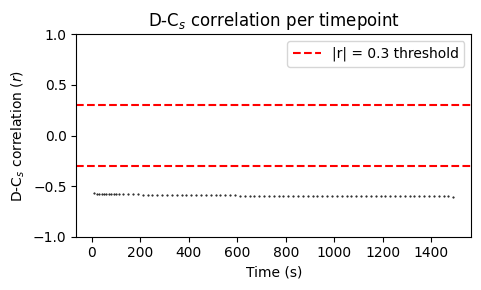

In [29]:
valid_idx = np.where(np.isfinite(opt_free["cs_per_t"]))[0]
dfree_csfree_corrs = [corrfree_per_t[i][0, 1] for i in valid_idx]
t_vals = [time[i] for i in valid_idx]

fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(t_vals, dfree_csfree_corrs,'o', ms = 0.5, mfc = 'k', mec = 'k')
ax.axhline(0.3, color='red', linestyle='--', label='|r| = 0.3 threshold')
ax.axhline(-0.3, color='red', linestyle='--')
ax.set_ylim(-1, 1)
ax.set_xlabel('Time (s)')
ax.set_ylabel(f'D-C$_s$ correlation ($r$)')
ax.set_title(f'D-C$_s$ correlation per timepoint')
ax.legend()
plt.tight_layout()
plt.show()

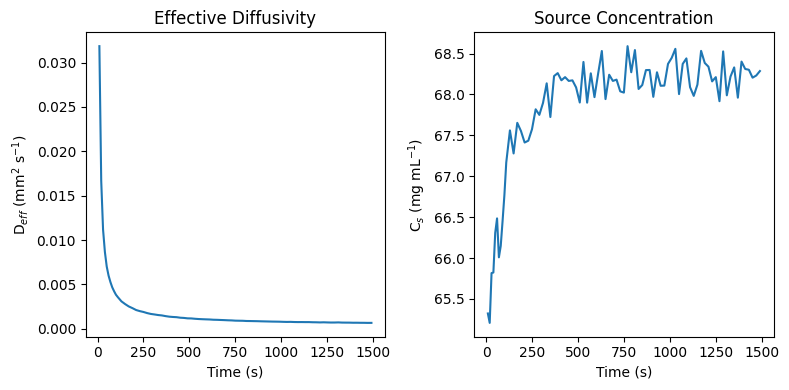

In [30]:
cs_free = opt_free['cs_per_t']
d_free = opt_free['d_per_t']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))
ax[0].plot(time, d_free)
ax[0].set_title(f"Effective Diffusivity")
ax[0].set_ylabel(f'D$_{{eff}}$ (mm$^2$ s$^{{-1}}$)')
ax[0].set_xlabel('Time (s)')
ax[1].plot(time, cs_free)
ax[1].set_title("Source Concentration")
ax[1].set_ylabel(f'C$_s$ (mg mL$^{{-1}}$)')
ax[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 2. Fixed D and Free Cs

In [31]:
opt_dglobal = diff_dglobal(c_xt = conc, x = depth, time = time)


Global fit complete.
D = 1.083e-03 mm2/s, SE = 1.428e-05 (95%CI [1.055e-03, 1.111e-03]
Note: SE and CI are symmetric (curve_fit linear approximation)
t = 10.0 s: Cs = 71.171, SE = 4.228 (95%CI [62.881, 79.461])
t = 20.0 s: Cs = 75.575, SE = 4.001 (95%CI [67.731, 83.419])
t = 30.0 s: Cs = 77.698, SE = 3.826 (95%CI [70.196, 85.200])
t = 40.0 s: Cs = 78.536, SE = 3.689 (95%CI [71.303, 85.770])
t = 50.0 s: Cs = 79.304, SE = 3.577 (95%CI [72.290, 86.318])
t = 60.0 s: Cs = 79.539, SE = 3.483 (95%CI [72.710, 86.368])
t = 70.0 s: Cs = 78.890, SE = 3.402 (95%CI [72.220, 85.560])
t = 80.0 s: Cs = 78.731, SE = 3.330 (95%CI [72.202, 85.261])
t = 90.0 s: Cs = 78.817, SE = 3.267 (95%CI [72.412, 85.223])
t = 100.0 s: Cs = 78.771, SE = 3.210 (95%CI [72.477, 85.064])
t = 110.0 s: Cs = 78.903, SE = 3.158 (95%CI [72.710, 85.095])
t = 130.0 s: Cs = 78.563, SE = 3.067 (95%CI [72.548, 84.577])
t = 150.0 s: Cs = 77.556, SE = 2.990 (95%CI [71.694, 83.417])
t = 170.0 s: Cs = 77.198, SE = 2.922 (95%CI [71.469,

In [32]:
# Correlation coefficient calculation
dglobal_csfree_corr = opt_dglobal['corr']
valid_idx = np.where(np.isfinite(opt_dglobal["cs_per_t"]))[0]

param_labels = ['D'] + [f"Cs_t{i}" for i in valid_idx]

print("--------")
print("D correlations with each CS")
print("--------")

corr_summary = {}
pos_corr = {}

for i, label in enumerate(param_labels[1:]):
    corr_t = dglobal_csfree_corr[0, i + 1]
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3: 
        pos_corr[label] = corr_t

if not pos_corr: 
    print("Weak to no correlations detected.")
else:
    for key in pos_corr.keys():
        print("Moderate to strong correlations detected:")
        print(f"D vs {key}: {pos_corr[key]:.3f}")

--------
D correlations with each CS
--------
Weak to no correlations detected.


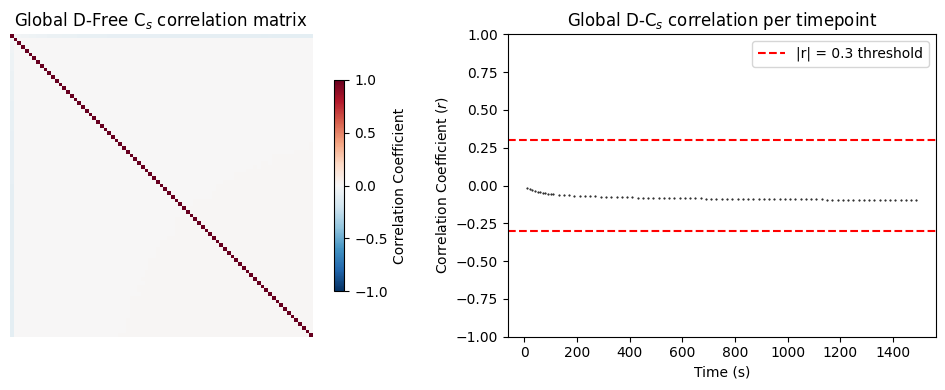

In [33]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize = (10, 4), gridspec_kw = {"width_ratios": [1, 1], "height_ratios": [1]})
# Correlation matrix
im = ax[0].imshow(dglobal_csfree_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax[0], label = "Correlation Coefficient", shrink = 0.7)
ax[0].set_title(f'Global D-Free C$_s$ correlation matrix')
ax[0].set_axis_off()

# Per-timepoint correlation (Global D vs. per-timepoint Cs)
t_vals = [time[i] for i in valid_idx]
ax[1].plot(t_vals, dglobal_csfree_corr[0, 1:], 'o', ms = 0.5, mfc = 'k', mec = 'k')
ax[1].set_ylim(-1, 1)
ax[1].axhline(y = -0.3, linestyle = "--", color = 'r')
ax[1].axhline(y = 0.3, linestyle = "--", color = 'r', label = '|r| = 0.3 threshold')
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel(f"Correlation Coefficient ($r$)")
ax[1].set_title(f"Global D-C$_s$ correlation per timepoint")
ax[1].legend()
plt.tight_layout()
plt.show()

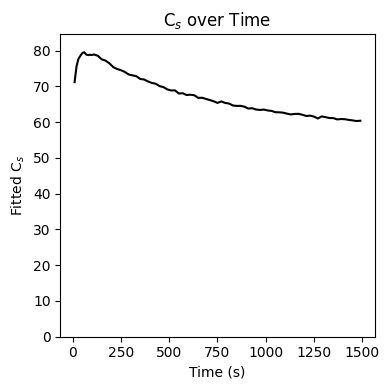

In [34]:
cs_opt = opt_dglobal['cs_per_t']

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot(time, cs_opt, color = 'k')
ax.set_ylim(0, (np.nanmax(cs_opt) + 5))
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Fitted C$_s$")
ax.set_ylim(0, np.nanmax(cs_opt) + 5)
ax.set_title(f"C$_s$ over Time")
plt.tight_layout()
plt.show()

## 3. Free D and Fixed Cs

In [35]:
opt_csglobal = diff_csglobal(c_xt = conc, x = depth, time = time)


Global fit complete.
Cs = 6.792e+01 mg/mL, SE = 1.306e-01 (95%CI [6.766e+01, 6.817e+01])
Note: SE and CI are symmetric (curve_fit linear approximation)
t = 10.0 s: D = 3.000e-02, SE = 1.399e-03 (95%CI [2.726e-02, 3.275e-02])
t = 20.0 s: D = 1.565e-02, SE = 7.219e-04 (95%CI [1.423e-02, 1.706e-02])
t = 30.0 s: D = 1.065e-02, SE = 4.888e-04 (95%CI [9.693e-03, 1.161e-02])
t = 40.0 s: D = 8.242e-03, SE = 3.753e-04 (95%CI [7.506e-03, 8.978e-03])
t = 50.0 s: D = 6.752e-03, SE = 3.057e-04 (95%CI [6.153e-03, 7.351e-03])
t = 60.0 s: D = 5.792e-03, SE = 2.603e-04 (95%CI [5.282e-03, 6.303e-03])
t = 70.0 s: D = 5.038e-03, SE = 2.256e-04 (95%CI [4.595e-03, 5.480e-03])
t = 80.0 s: D = 4.480e-03, SE = 1.998e-04 (95%CI [4.088e-03, 4.872e-03])
t = 90.0 s: D = 4.084e-03, SE = 1.810e-04 (95%CI [3.729e-03, 4.439e-03])
t = 100.0 s: D = 3.737e-03, SE = 1.650e-04 (95%CI [3.414e-03, 4.061e-03])
t = 110.0 s: D = 3.508e-03, SE = 1.536e-04 (95%CI [3.207e-03, 3.809e-03])
t = 130.0 s: D = 3.058e-03, SE = 1.329e-04

In [36]:
# Correlation coefficient calculation
dfree_csglobal_corr = opt_csglobal['corr']
valid_idx = np.where(np.isfinite(opt_csglobal["d_per_t"]))[0]

param_labels = ['Cs'] + [f"D_t{i}" for i in valid_idx]

print("--------")
print("D correlations with each CS")
print("--------")

corr_summary = {}
pos_corr = {}

for i, label in enumerate(param_labels[1:]):
    corr_t = dfree_csglobal_corr[0, i + 1]
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3: 
        pos_corr[label] = corr_t

if not pos_corr: 
    print("Weak to no correlations detected.")
else:
    print("Moderate to strong correlations detected:")
    for key in pos_corr.keys():
        print(f"D vs {key}: {pos_corr[key]:.3f}")

--------
D correlations with each CS
--------
Weak to no correlations detected.


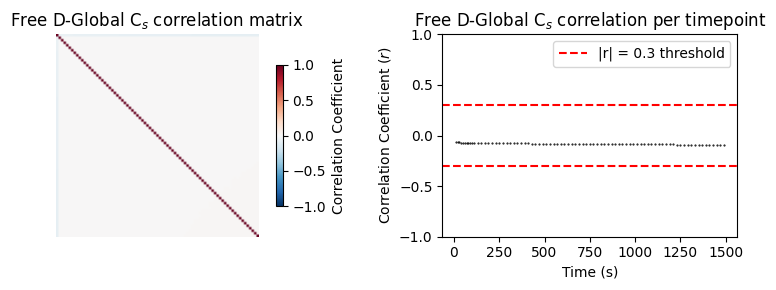

In [37]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize = (8, 3), gridspec_kw = {"width_ratios": [1.2, 1], "height_ratios": [1]})
# Correlation matrix
im = ax[0].imshow(dfree_csglobal_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax[0], label = "Correlation Coefficient", shrink = 0.7)
ax[0].set_title(f'Free D-Global C$_s$ correlation matrix')
ax[0].set_axis_off()

# Per-timepoint correlation (Global D vs. per-timepoint Cs)
t_vals = [time[i] for i in valid_idx]
ax[1].plot(t_vals, dfree_csglobal_corr[0, 1:], 'o', ms = 0.5, mfc = 'k', mec = 'k')
ax[1].set_ylim(-1, 1)
ax[1].axhline(y = -0.3, linestyle = "--", color = 'r')
ax[1].axhline(y = 0.3, linestyle = "--", color = 'r', label = '|r| = 0.3 threshold')
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel(f"Correlation Coefficient ($r$)")
ax[1].set_title(f"Free D-Global C$_s$ correlation per timepoint")
ax[1].legend()
plt.tight_layout()
plt.show()

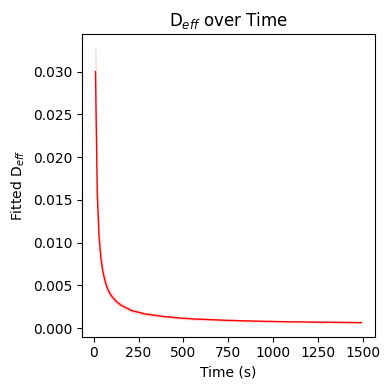

In [38]:
d_opt = opt_csglobal['d_per_t']
d_lb = opt_csglobal['lb_all']
d_ub = opt_csglobal['ub_all']

d_opt[0] = np.nan
d_lb[0] = np.nan
d_ub[0] = np.nan

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot(time, d_opt, color = 'r', lw = 1)
ax.fill_between(time,
               d_lb, d_ub,
               color = 'red',
               alpha = 0.1)
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Fitted D$_{{eff}}$")
ax.set_title(f"D$_{{eff}}$ over Time")
plt.tight_layout()
plt.show()

## 4. Fixed D and Cs

In [39]:
opt_global = diff_global(c_xt = conc, x = depth, time = time)


Global fit complete.
D = 1.022e-03, Cs = 6.677e+01 mg/mL, SE = 3.312e-01 (95%CI [6.612e+01, 6.742e+01]
Note: SE and CI are symmetric (curve_fit linear approximation)
Mean per-timepoint R2 = 0.9217

Correlation matrix:
                  Cs         D
        Cs 1.000e+00-5.903e-01
         D-5.903e-01 1.000e+00


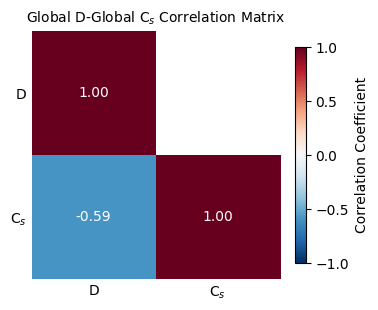

In [40]:
# Plotting correlation matrix
dglobal_csglobal_corr = opt_global['corr']
labels = ["D", f"C$_s$"]

# Mask upper triangle
mask = np.triu(np.ones_like(dglobal_csglobal_corr, dtype = bool), k = 1)

# Apply mask
masked_corr = np.ma.masked_where(mask, dglobal_csglobal_corr)

fig, ax = plt.subplots(figsize = (4, 4))
im = ax.imshow(masked_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax, label = 'Correlation Coefficient', shrink = 0.7)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.tick_params(length = 0)

# add values to cells
for i in range(masked_corr.shape[0]):
    for j in range(masked_corr.shape[1]):
        if not mask[i, j]:
            ax.text(
                j, i,
                f"{dglobal_csglobal_corr[i, j]:.2f}",
                ha = 'center',
                va = 'center',
                color = 'white'
            )

# Remove border box
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f"Global D-Global C$_s$ Correlation Matrix", fontdict = {"size": 10})
plt.show()

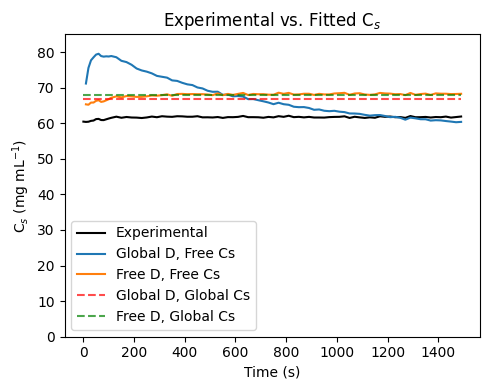

In [41]:
# Cs values
first_row = conc[:, 0] # experimental
cs_dfixed = opt_dglobal['cs_per_t']
cs_dfree = opt_csglobal['cs_global']
cs_free = opt_free['cs_per_t']
cs_glob = opt_global['cs_global']

fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(time, first_row, label = 'Experimental', color = 'k')
ax.plot(time, cs_dfixed, label = 'Global D, Free Cs')
ax.plot(time, cs_free, label = 'Free D, Free Cs')
ax.hlines(y = cs_glob, xmin = np.nanmin(time), xmax = np.nanmax(time), 
          label = 'Global D, Global Cs', 
          color = 'red', linestyle = '--', alpha = 0.7)
ax.hlines(y = cs_dfree, xmin = np.nanmin(time), xmax = np.nanmax(time), 
          label = 'Free D, Global Cs', 
          color = 'green', linestyle = '--', alpha = 0.7)
ax.legend()
ax.set_ylim(0, 85)
ax.set_title(f"Experimental vs. Fitted C$_s$")
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"C$_s$ (mg mL$^{{-1}})$")

plt.tight_layout()
plt.show()

# Sensitivity Analyses

## 1. Fixing Cs to experimental Cs 
- Cs is consistently overestimated when compared to *experimental* Cs
- Negative correlation in most fittings - Cs overestimated and D underestimated
- May be due to profile in earlier timepoints being too steep -> unable to fit properly
- Due to these, D is not actually time-varying, but constant.

In [42]:
# Mean experimental Cs
mean_exp_cs = np.nanmean(first_row)
res_mean_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = mean_exp_cs
)

# Per-timepoint experimental CS
exp_cs = first_row
res_per_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = exp_cs)



Global D fit complete.
D = 1.159e-03, SE = 1.404e-05 (95%CI [1.132e-03, 1.187e-03]
Mean per-timepoint R2 = 0.9173

Per-timepoint D fit:
t = 10.0 s: Cs = 61.625, D = 3.478e-02, SE = 1.577e-03 (95% CI[3.160e-02, 3.797e-02]), R2 = 0.9883
t = 20.0 s: Cs = 61.625, D = 1.819e-02, SE = 8.027e-04 (95% CI[1.657e-02, 1.981e-02]), R2 = 0.9888
t = 30.0 s: Cs = 61.625, D = 1.234e-02, SE = 5.893e-04 (95% CI[1.115e-02, 1.353e-02]), R2 = 0.9871
t = 40.0 s: Cs = 61.625, D = 9.562e-03, SE = 4.493e-04 (95% CI[8.655e-03, 1.047e-02]), R2 = 0.9874
t = 50.0 s: Cs = 61.625, D = 7.822e-03, SE = 3.776e-04 (95% CI[7.060e-03, 8.584e-03]), R2 = 0.9868
t = 60.0 s: Cs = 61.625, D = 6.716e-03, SE = 3.375e-04 (95% CI[6.035e-03, 7.397e-03]), R2 = 0.9856
t = 70.0 s: Cs = 61.625, D = 5.843e-03, SE = 2.756e-04 (95% CI[5.287e-03, 6.400e-03]), R2 = 0.9872
t = 80.0 s: Cs = 61.625, D = 5.192e-03, SE = 2.487e-04 (95% CI[4.690e-03, 5.693e-03]), R2 = 0.9868
t = 90.0 s: Cs = 61.625, D = 4.734e-03, SE = 2.328e-04 (95% CI[4.264e-0

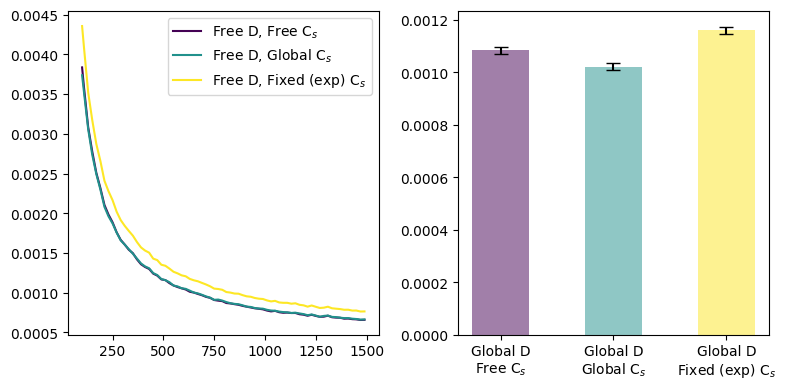

In [43]:
# ---- Plotting ----
# -- Fixed D --
dglob_cfree = opt_dglobal['d_global']
dglob_cglob = opt_global['d_global']
dglob_cfixedm = res_mean_cs['d_global']
# - Errors - 
dgcf_sem = opt_dglobal['se_d']
dgcg_sem = opt_global['se_d']
dgcfm_sem = res_mean_cs['se_d_global']

# -- Per-timepoint D --
dfree_cfree = opt_free['d_per_t']
dfree_cglob = opt_csglobal['d_per_t']
dfree_cfixed = res_per_cs['d_per_t']

# -- Plot --
fig, ax = plt.subplots(1, 2, figsize = (8, 4))

cmap = plt.get_cmap('viridis')
n_fits = 3
x_pos = np.arange(n_fits)
colors = cmap(np.linspace(0, 1, n_fits))

fd = ax[0] # global d
gd = ax[1] # free d

dfcf = fd.plot(time[10:], dfree_cfree[10:],
       label = 'Free D, Free C$_s$',
              color = colors[0])
dfcg = fd.plot(time[10:], dfree_cglob[10:],
       label = 'Free D, Global C$_s$',
              color = colors[1])
dfcfixed = fd.plot(time[10:], dfree_cfixed[10:],
       label = 'Free D, Fixed (exp) C$_s$',
                  color = colors[2])
fd.legend()

gd.bar(x_pos,
       [dglob_cfree,
       dglob_cglob,
       dglob_cfixedm],
       yerr = [dgcf_sem, dgcg_sem, dgcfm_sem],
       color = colors,
      alpha = 0.5,
      capsize = 5,
      width = 0.5)
gd.set_xticks(x_pos)
gd.set_xticklabels([f"Global D\nFree C$_s$",
                   f"Global D\nGlobal C$_s$",
                   f"Global D\nFixed (exp) C$_s$"])

plt.tight_layout()
plt.show()

## 2. Shifting `valid_indices` to identify informative timepoints
- From (1), earlier timepoints give an unstable fitting of D and may introduce bias
- Excluding uninformative timepoints may give a more precise fitting of D
> **Objective**: See whether shifting `valid_indices` (fitted timepoints) would eventually lead to a stabilized fitted D

In [44]:
# --- Loading variables ---
# Per-timepoint experimental CS
exp_cs = first_row
res_per_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = exp_cs, print_res = False)

In [45]:
res_per_cs.keys()

dict_keys(['d_global', 'se_d_global', 'lb_d_global', 'ub_d_global', 'd_per_t', 'se_d_per_t', 'lb_d_per_t', 'ub_d_per_t', 'r2_per_t', 'r2_global'])

In [46]:
time

array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
         90.,  100.,  110.,  130.,  150.,  170.,  190.,  210.,  230.,
        250.,  270.,  290.,  310.,  330.,  350.,  370.,  390.,  410.,
        430.,  450.,  470.,  490.,  510.,  530.,  550.,  570.,  590.,
        610.,  630.,  650.,  670.,  690.,  710.,  730.,  750.,  770.,
        790.,  810.,  830.,  850.,  870.,  890.,  910.,  930.,  950.,
        970.,  990., 1010., 1030., 1050., 1070., 1090., 1110., 1130.,
       1150., 1170., 1190., 1210., 1230., 1250., 1270., 1290., 1310.,
       1330., 1350., 1370., 1390., 1410., 1430., 1450., 1470., 1490.])

In [47]:
# --- Varying timepoint to fit ---
idx_list = []

start_idx = 1
end = len(time)
for i in range(len(time)):
    indices = np.arange(start_idx, end)
    idx_list += [indices]
    if time[start_idx] < 130:
        start_idx += 6
    elif time[start_idx] > 130 and start_idx < end - 6:
        start_idx += 3
    else:
        break

In [48]:
# iterating through each list of indices
varidx_d = []
varidx_d_se = []
varidx_d_lb = []
varidx_d_ub = []
varidx_r2 = [] # global r2

for idx in idx_list:
    opt = diff_csfixed(
        c_xt = conc, x = depth, time = time,
        fit_indices = idx,
        cs_fixed = exp_cs, print_res = False
    )
    varidx_d += [opt["d_global"]]
    varidx_d_se += [opt["se_d_global"]]
    varidx_d_lb += [opt["lb_d_global"]]
    varidx_d_ub += [opt["ub_d_global"]]
    varidx_r2 += [opt["r2_global"]]

In [49]:
# ---- Preparing for plotting ----
first_idx = [list[0] for list in idx_list]
first_time = [time[i] for i in first_idx]

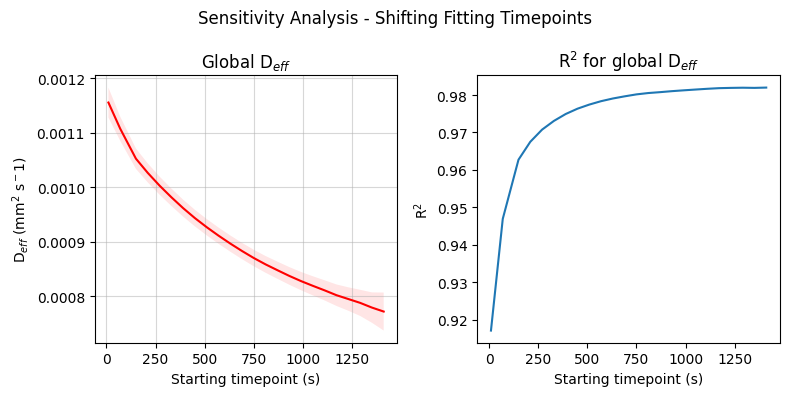

In [95]:
# ---- Plotting ----
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
ax[0].plot(first_time, varidx_d, color = 'r')
ax[0].fill_between(first_time, 
                   varidx_d_lb, varidx_d_ub,
                   facecolor = 'red',
                   alpha = 0.1)
ax[0].grid(alpha = 0.5)
ax[0].set_title(f"Global D$_{{eff}}$")
ax[0].set_xlabel("Starting timepoint (s)")
ax[0].set_ylabel(f"D$_{{eff}}$ (mm$^2$ s$^{-1}$)")
ax[1].plot(first_time, varidx_r2)
ax[1].set_xlabel("Starting timepoint (s)")
ax[1].set_ylabel("R$^2$")
ax[1].set_title(f"R$^2$ for global D$_{{eff}}$")
fig.suptitle("Sensitivity Analysis - Shifting Fitting Timepoints")
plt.tight_layout()
plt.show()

Fitted global $D$ values not stabilizing.

In [51]:
import pandas as pd

dat = {"starting timepoint": first_time,
       "global_d": varidx_d,
       "global_d_se": varidx_d_se}

df = pd.DataFrame(dat)

## 3. Adjusting ROI size
Large ROI sizes may include uninformative rows and artificially underestimate D. Shifting ROI size to see if D is affected.

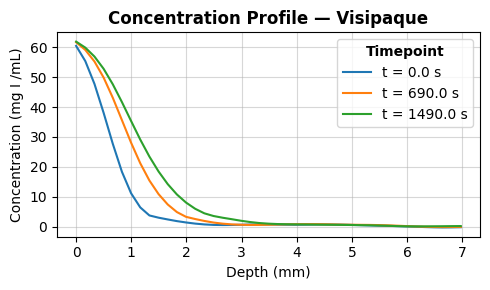

In [98]:
prof_t0 = conc[0, :]
prof_t40 = conc[40, :]
prof_t81 = conc[80, :]

fig, ax = plt.subplots(figsize = (5, 3))
ax.plot(depth, prof_t0, label = f"t = {time[0]} s")
ax.plot(depth, prof_t40, label = f"t = {time[40]} s")
ax.plot(depth, prof_t81, label = f"t = {time[80]} s")
ax.legend(title = "Timepoint", title_fontproperties = {"weight": "bold"})
ax.set_ylabel("Concentration (mg I /mL)")
ax.set_xlabel("Depth (mm)")
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", fontdict = {"weight": "bold"})
plt.tight_layout()
plt.show()

In [140]:
conc.shape[0] == len(time)

True

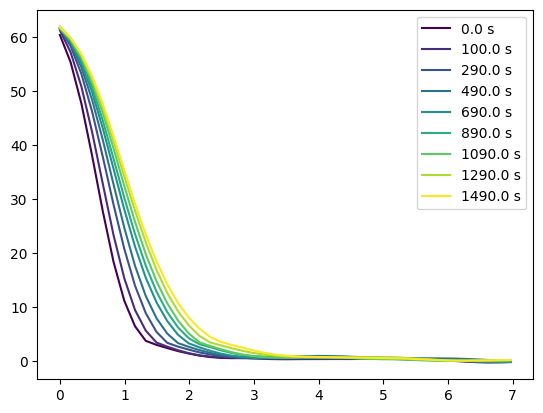

In [166]:
n_profs = len(range(0, len(time), 10))
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots()
j = 0
for i in range(0, len(time), 10):
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend()


In [197]:
time_t = time[1:]
conc_t = conc[1:, :]

time_grid, depth_grid = np.meshgrid(time_t, depth, indexing = "ij")

eta_grid = depth_grid / np.sqrt(time_grid)

eta_flat = eta_grid.ravel()
conc_flat = conc_t.ravel()

In [202]:
conc_t

array([[ 6.03814670e+01,  5.56221355e+01,  4.82829981e+01, ...,
        -1.68117682e-02, -4.28299810e-02, -6.88481937e-02],
       [ 6.04355049e+01,  5.57041929e+01,  4.84751326e+01, ...,
         1.57310117e-01,  8.72610828e-02,  2.12148504e-02],
       [ 6.06736716e+01,  5.61645152e+01,  4.91596117e+01, ...,
         2.21354948e-01,  1.77324127e-01,  1.43300310e-01],
       ...,
       [ 6.15963174e+01,  5.96529571e+01,  5.67449214e+01, ...,
         9.92694886e-02,  1.07275093e-01,  1.41298909e-01],
       [ 6.17484239e+01,  5.96509557e+01,  5.66448514e+01, ...,
         3.01410988e-01,  2.49374562e-01,  2.23356349e-01],
       [ 6.18965276e+01,  5.98931252e+01,  5.69050335e+01, ...,
         1.25287701e-01,  1.57310117e-01,  1.81326929e-01]],
      shape=(80, 43))

In [201]:
eta_grid

array([[0.        , 0.05249381, 0.10498762, ..., 2.09975237, 2.15224618,
        2.20473998],
       [0.        , 0.03711873, 0.07423746, ..., 1.48474914, 1.52186787,
        1.55898659],
       [0.        , 0.03030731, 0.06061463, ..., 1.21229259, 1.24259991,
        1.27290722],
       ...,
       [0.        , 0.00435937, 0.00871875, ..., 0.17437494, 0.17873432,
        0.18309369],
       [0.        , 0.00432962, 0.00865923, ..., 0.17318466, 0.17751427,
        0.18184389],
       [0.        , 0.00430046, 0.00860092, ..., 0.17201842, 0.17631888,
        0.18061934]], shape=(80, 43))

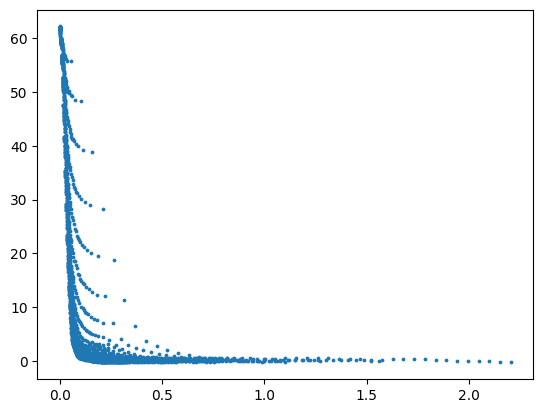

In [200]:
fig, ax = plt.subplots()
ax.scatter(eta_flat, conc_flat, s = 3)